In [1]:
import pandas as pd
import lightgbm as lgb

# 1. データの読み込み（文字コードを Shift-JIS に指定）
train = pd.read_csv('data/train.csv', encoding='shift-jis')
test = pd.read_csv('data/test.csv', encoding='shift-jis')

# ※もし上記でまだエラーが出る場合は、'shift-jis' の代わりに 'cp932' を試してください。
# train = pd.read_csv('train.csv', encoding='cp932')
# test = pd.read_csv('test.csv', encoding='cp932')

# 2. 特徴量（X）と目的変数（y）の切り分け
drop_cols_train = ['sample number', '樹種', '含水率']
X_train = train.drop(columns=drop_cols_train)
y_train = train['含水率']

drop_cols_test = ['sample number', '樹種']
X_test = test.drop(columns=drop_cols_test)

# 3. LightGBMモデルの定義と学習
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# 4. テストデータに対する予測
test_preds = model.predict(X_test)

# 5. sample_submit.csv と同じ形式で提出用ファイルを作成
submission = pd.DataFrame({
    'sample_number': test['sample number'],
    '含水率': test_preds
})

# ヘッダーやインデックスを含めずにCSVとして保存
submission.to_csv('submission_baseline.csv', header=False, index=False)

print("学習と予測が完了しました。")
print("提出用ファイル 'submission_baseline.csv' が作成されました。")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 396539
[LightGBM] [Info] Number of data points in the train set: 1322, number of used features: 1556
[LightGBM] [Info] Start training from score 49.937672
学習と予測が完了しました。
提出用ファイル 'submission_baseline.csv' が作成されました。


In [6]:
import pandas as pd
import numpy as np

# 1. データの読み込み（trainとtestの両方）
with open('data/train.csv', 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)

with open('data/test.csv', 'r', encoding='cp932', errors='replace') as f:
    test = pd.read_csv(f)

# 2. 波数のカラム（光の種類の列）を特定する
meta_cols_train = ['sample number', 'species number', '樹種', '含水率']
spec_cols = [col for col in train.columns if col not in meta_cols_train]

# 3. SNV（標準化）を行う関数を作る
# 何度も使い回せるように関数化しておくと便利です
def apply_snv(df, cols):
    X = df[cols].values
    # 行ごとに平均と標準偏差を計算
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    # 標準化
    X_snv = (X - mean) / (std + 1e-8)
    
    # 処理したデータで上書きした新しいデータフレームを返す
    df_snv = df.copy()
    df_snv[cols] = X_snv
    return df_snv

# 4. 学習データとテストデータの【両方】にSNVを適用！
train_snv = apply_snv(train, spec_cols)
test_snv = apply_snv(test, spec_cols)

print("学習データのSNV処理完了！ (サイズ:", train_snv.shape, ")")
print("テストデータのSNV処理完了！ (サイズ:", test_snv.shape, ")")

学習データのSNV処理完了！ (サイズ: (1322, 1559) )
テストデータのSNV処理完了！ (サイズ: (550, 1558) )


In [7]:
import pandas as pd

# データの読み込み
with open('data/train.csv', 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)

# 各カラムの欠損値の数をカウント
missing_values = train.isnull().sum()

# 欠損値が1つ以上あるカラムだけを抽出
cols_with_missing = missing_values[missing_values > 0]

print(f"全体のカラム数: {len(train.columns)}")
print(f"欠損値が含まれるカラム数: {len(cols_with_missing)}")

if len(cols_with_missing) > 0:
    print("\n【欠損値があるカラムと、その欠損数】")
    print(cols_with_missing)
else:
    print("\n欠損値は1つも見つかりませんでした！データは綺麗です。")

全体のカラム数: 1559
欠損値が含まれるカラム数: 0

欠損値は1つも見つかりませんでした！データは綺麗です。


In [10]:
import pandas as pd

# 1. データの読み込み（エンコーディングはこれまでの設定に合わせます）
path_train = 'data/train.csv'
path_test = 'data/test.csv'

try:
    with open(path_train, 'r', encoding='cp932', errors='replace') as f:
        train = pd.read_csv(f)
    with open(path_test, 'r', encoding='cp932', errors='replace') as f:
        test = pd.read_csv(f)
    
    # 2. 樹種ごとのサンプル数を集計
    # 学習データ
    train_counts = train.groupby(['species number', '樹種']).size().reset_index(name='Train件数')
    # テストデータ
    test_counts = test.groupby(['species number', '樹種']).size().reset_index(name='Test件数')

    # 3. 両方の集計を結合（横に並べる）
    species_summary = pd.merge(train_counts, test_counts, on=['species number', '樹種'], how='outer').fillna(0)

    # 件数を整数型に直して表示
    species_summary['Train件数'] = species_summary['Train件数'].astype(int)
    species_summary['Test件数'] = species_summary['Test件数'].astype(int)

    print("【樹種ごとのサンプル分布一覧】")
    print("-" * 50)
    print(species_summary.sort_values('species number').to_string(index=False))
    print("-" * 50)

    # 4. 未知の樹種がないかチェック
    unseen_species = species_summary[species_summary['Train件数'] == 0]
    if len(unseen_species) > 0:
        print("\n⚠️ 警告: テストデータにのみ存在する樹種が見つかりました！")
        print(unseen_species[['species number', '樹種']])
    else:
        print("\n✅ 安心: すべてのテストデータの樹種が、学習データにも含まれています。")

except FileNotFoundError as e:
    print(f"エラー: ファイルが見つかりません。パスを確認してください。({e})")

【樹種ごとのサンプル分布一覧】
--------------------------------------------------
 species number      樹種  Train件数  Test件数
              1    イチョウ       94       0
              2    クスノキ        0      96
              3    ウエンジ       87       0
              4 ウォールナット      110       0
              5      クリ       91       0
              6     ケヤキ        0      63
              7      スギ        0     192
              8   スプルース       97       0
              9      タモ        0      45
             10     チーク        0     101
             11    チェリー       88       0
             12      トチ      183       0
             13      ナラ      107       0
             14     ヒノキ      141       0
             15    ベイスギ      112       0
             16     米ヒバ       68       0
             17    ベイマツ       93       0
             18   ヤマザクラ        0      53
             19 ホワイトオーク       51       0
--------------------------------------------------

⚠️ 警告: テストデータにのみ存在する樹種が見つかりました！
    species number     樹種
1  

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold

# データの読み込み（openを使ってエラーを回避）
with open('data/train.csv', 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)

y = train['含水率']
groups = train['species number']
species_names = train['樹種']

gkf = GroupKFold(n_splits=5)

print("🔍 各Foldに含まれる樹種と含水率の調査\n" + "="*50)

for fold, (train_idx, valid_idx) in enumerate(gkf.split(train, y, groups)):
    # このFoldで「未知の樹種」としてテストされるデータを抽出
    valid_species_nums = groups.iloc[valid_idx].unique()
    valid_species_names = species_names.iloc[valid_idx].unique()
    valid_y = y.iloc[valid_idx]
    
    print(f"【Fold {fold+1}】")
    print(f"  ▶ テストされた樹種: {valid_species_names} (番号: {valid_species_nums})")
    print(f"  ▶ データ数: {len(valid_y)}件")
    print(f"  ▶ 含水率の平均: {valid_y.mean():.2f}%")
    print(f"  ▶ 含水率の最小〜最大: {valid_y.min():.2f}% 〜 {valid_y.max():.2f}%")
    print("-" * 50)

🔍 各Foldに含まれる樹種と含水率の調査
【Fold 1】
  ▶ テストされた樹種: ['チェリー' 'トチ'] (番号: [11 12])
  ▶ データ数: 271件
  ▶ 含水率の平均: 38.69%
  ▶ 含水率の最小〜最大: 4.15% 〜 158.92%
--------------------------------------------------
【Fold 2】
  ▶ テストされた樹種: ['クリ' 'ヒノキ'] (番号: [ 5 14])
  ▶ データ数: 232件
  ▶ 含水率の平均: 52.77%
  ▶ 含水率の最小〜最大: 0.97% 〜 198.54%
--------------------------------------------------
【Fold 3】
  ▶ テストされた樹種: ['ベイスギ' 'ベイマツ' 'ホワイトオーク'] (番号: [15 17 19])
  ▶ データ数: 256件
  ▶ 含水率の平均: 60.49%
  ▶ 含水率の最小〜最大: 2.59% 〜 298.58%
--------------------------------------------------
【Fold 4】
  ▶ テストされた樹種: ['イチョウ' 'ウエンジ' 'ウォールナット'] (番号: [1 3 4])
  ▶ データ数: 291件
  ▶ 含水率の平均: 51.45%
  ▶ 含水率の最小〜最大: 4.22% 〜 216.13%
--------------------------------------------------
【Fold 5】
  ▶ テストされた樹種: ['スプルース' 'ナラ' '米ヒバ'] (番号: [ 8 13 16])
  ▶ データ数: 272件
  ▶ 含水率の平均: 47.18%
  ▶ 含水率の最小〜最大: 0.84% 〜 180.54%
--------------------------------------------------


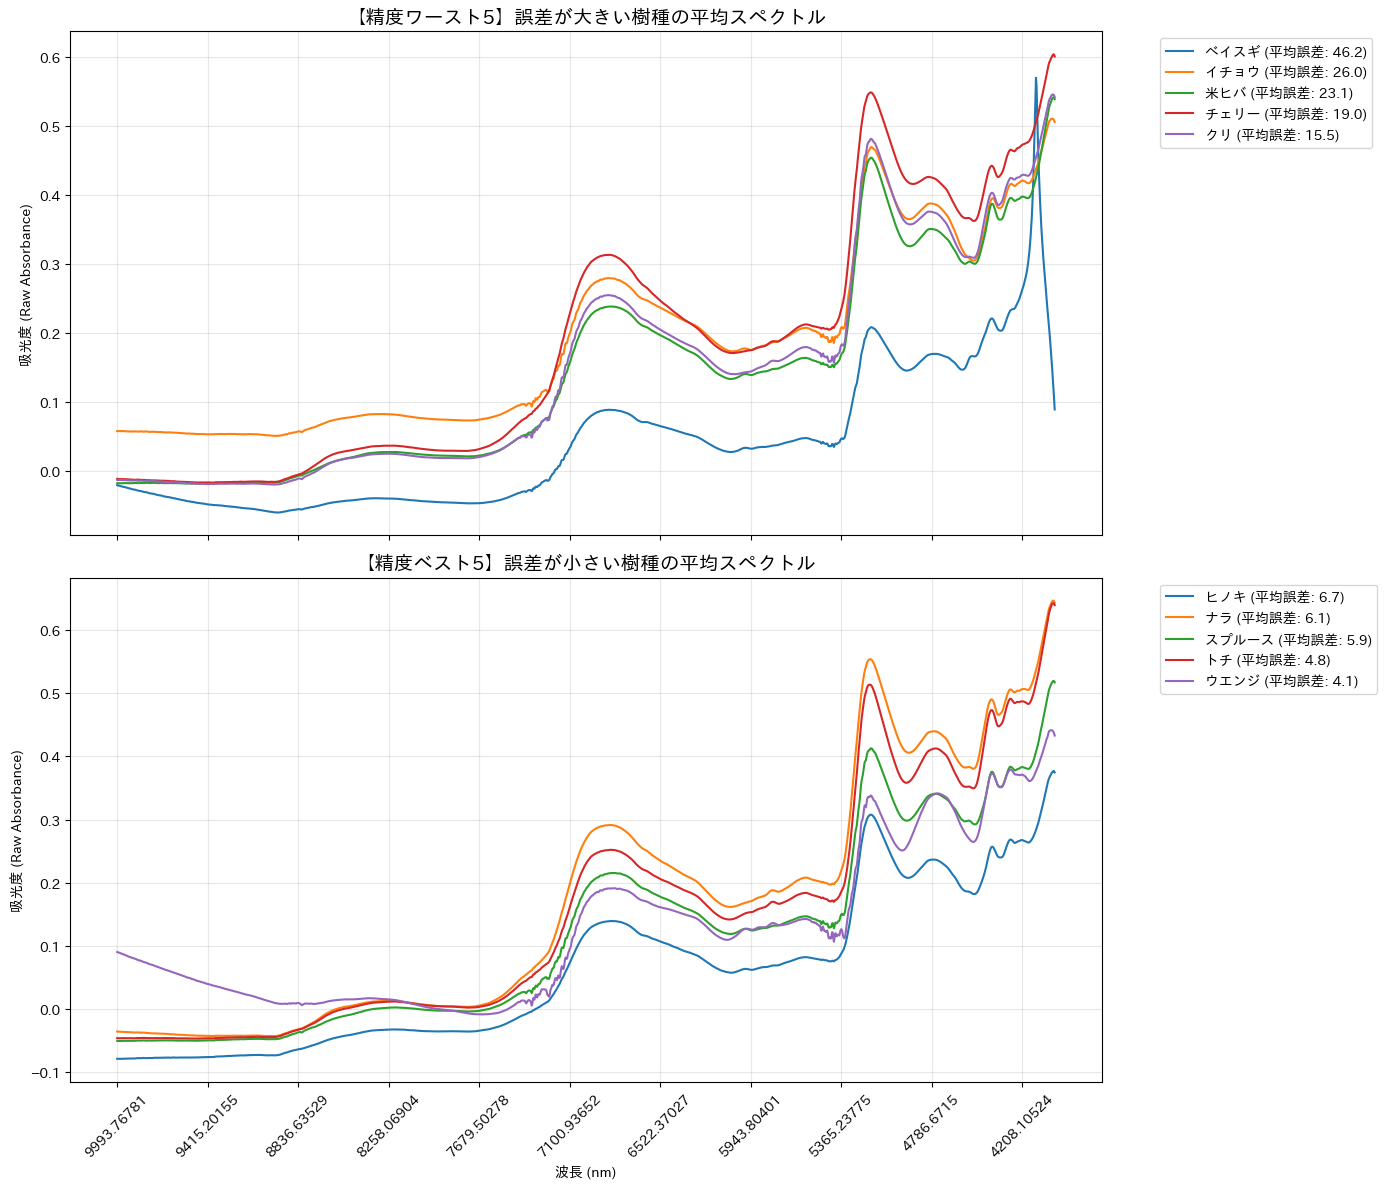

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. 樹種ごとの平均誤差を計算
results = pd.DataFrame({'樹種': train_raw['樹種'], '実測': y_raw, '予測': oof_preds_raw})
results['誤差'] = np.abs(results['実測'] - results['予測'])
avg_error = results.groupby('樹種')['誤差'].mean().sort_values(ascending=False)

# ワースト5（誤差が大きい）と ベスト5（誤差が小さい）を抽出
worst_5 = avg_error.head(5).index.tolist()
best_5 = avg_error.tail(5).index.tolist()

# 2. プロット作成
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# --- 上段：ワースト5樹種（精度が悪いグループ） ---
for s in worst_5:
    subset = train_raw[train_raw['樹種'] == s]
    # 代表として各樹種の平均スペクトルを表示
    ax1.plot(spec_cols, subset[spec_cols].mean(), label=f"{s} (平均誤差: {avg_error[s]:.1f})")

ax1.set_title("【精度ワースト5】誤差が大きい樹種の平均スペクトル", fontsize=14)
ax1.set_ylabel("吸光度 (Raw Absorbance)")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# --- 下段：ベスト5樹種（精度が良いグループ） ---
for s in best_5:
    subset = train_raw[train_raw['樹種'] == s]
    ax2.plot(spec_cols, subset[spec_cols].mean(), label=f"{s} (平均誤差: {avg_error[s]:.1f})")

ax2.set_title("【精度ベスト5】誤差が小さい樹種の平均スペクトル", fontsize=14)
ax2.set_xlabel("波長 (nm)")
ax2.set_ylabel("吸光度 (Raw Absorbance)")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# X軸のメモリ調整
plt.xticks(spec_cols[::150], rotation=45)
plt.tight_layout()
plt.show()

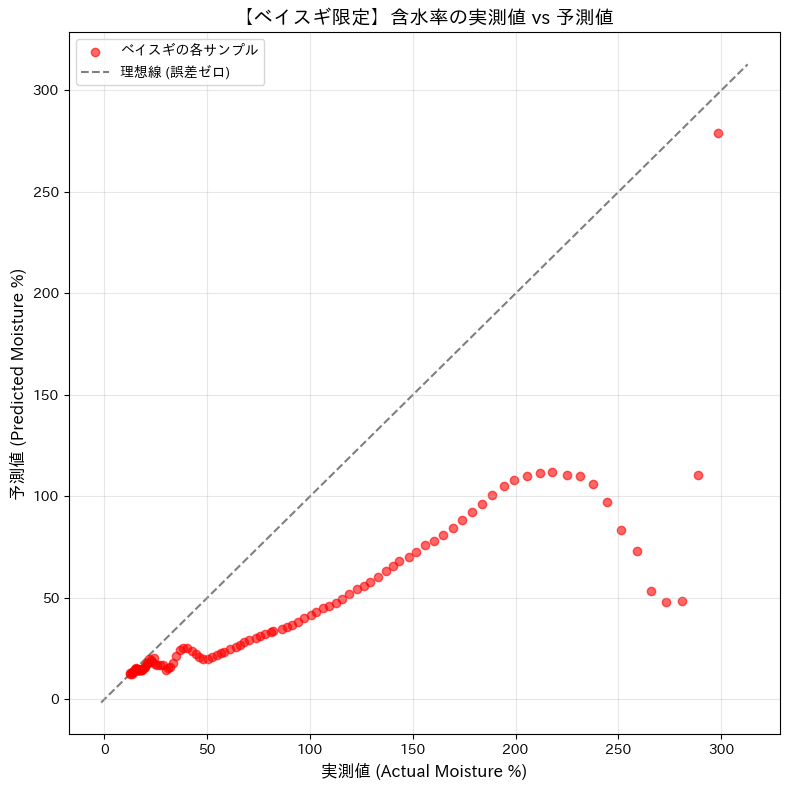

🌲 ベイスギの統計データ:
  - 実測値の範囲: 12.8% 〜 298.6%
  - 予測値の範囲: 12.6% 〜 278.8%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. ベイスギのデータのみを抽出
cedar_results = results[results['樹種'] == 'ベイスギ']

# 2. 散布図の作成
plt.figure(figsize=(8, 8))

# 実測と予測の散布
plt.scatter(cedar_results['実測'], cedar_results['予測'], 
            alpha=0.6, color='red', label='ベイスギの各サンプル')

# 理想的な線 (y = x)
lims = [
    np.min([plt.xlim()[0], plt.ylim()[0]]),  # 最小値
    np.max([plt.xlim()[1], plt.ylim()[1]]),  # 最大値
]
plt.plot(lims, lims, 'k--', alpha=0.5, zorder=0, label='理想線 (誤差ゼロ)')

plt.title("【ベイスギ限定】含水率の実測値 vs 予測値", fontsize=14)
plt.xlabel("実測値 (Actual Moisture %)", fontsize=12)
plt.ylabel("予測値 (Predicted Moisture %)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 統計量の表示
print(f"🌲 ベイスギの統計データ:")
print(f"  - 実測値の範囲: {cedar_results['実測'].min():.1f}% 〜 {cedar_results['実測'].max():.1f}%")
print(f"  - 予測値の範囲: {cedar_results['予測'].min():.1f}% 〜 {cedar_results['予測'].max():.1f}%")

今一番精度の良いやつ

In [4]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from scipy.signal import savgol_filter
import os
import warnings

warnings.filterwarnings('ignore')

# --- 1. データの読み込み ---
train_path = 'data/train.csv'
test_path = 'data/test.csv'
submit_path = 'data/sample_submit.csv'

print("📂 データを読み込んでいます...")
with open(train_path, 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)
with open(test_path, 'r', encoding='cp932', errors='replace') as f:
    test = pd.read_csv(f)
submit = pd.read_csv(submit_path, header=None)

# 波数カラムの特定
spec_cols = [col for col in train.columns if col not in ['sample number', 'species number', '樹種', '含水率']]

# 外れ値対策の対数変換
y_train_log = np.log1p(train['含水率'])
groups = train['species number']

# 🌟 特定の波長（1000nmと1100nm）に近いカラムを探す
wavenumbers = np.array([float(c) for c in spec_cols])
col_1000nm = spec_cols[np.argmin(np.abs(wavenumbers - (10000000 / 1000)))]
col_1100nm = spec_cols[np.argmin(np.abs(wavenumbers - (10000000 / 1100)))]

# --- 2. 前処理（フル解像度 + SNV/微分 + 文脈 + 物理センサー） ---
def preprocess_features(df, spec_cols):
    X_raw = df[spec_cols].values
    
    # ① 広葉樹攻略用の物理センサー（生の波形から計算）
    darkness_proxy = np.mean(X_raw, axis=1).reshape(-1, 1)
    scattering_tilt = (df[col_1000nm] - df[col_1100nm]).values.reshape(-1, 1)
    
    # ② SNV (波形の形を抽出)
    m = np.mean(X_raw, axis=1, keepdims=True)
    s = np.std(X_raw, axis=1, keepdims=True)
    X_snv = (X_raw - m) / (s + 1e-8)
    
    # ③ 1次微分 (山の傾きを抽出)
    X_diff = savgol_filter(X_snv, window_length=15, polyorder=2, deriv=1)
    
    snv_cols = [f"snv_{c}" for c in spec_cols]
    diff_cols = [f"diff_{c}" for c in spec_cols]
    
    # 一旦DataFrame化
    df_features = pd.DataFrame(
        np.hstack([X_snv, X_diff, darkness_proxy, scattering_tilt]), 
        columns=snv_cols + diff_cols + ['darkness_proxy', 'scattering_tilt'], 
        index=df.index
    )
    
    df_features['樹種'] = df['樹種'].values
    
    # ④ 測定回数の文脈
    df_features['record_count'] = df_features.groupby('樹種').cumcount() + 1
    
    print("  - 時間的な文脈（ラグ・移動平均）を計算中...")
    # ⑤ ラグ・移動平均（SNV波形に対して適用）
    lag_df = df_features.groupby('樹種')[snv_cols].shift(1)
    lag_df.columns = [f"{c}_lag1" for c in snv_cols]
    
    roll_df = df_features.groupby('樹種')[snv_cols].rolling(window=5, min_periods=1).mean()
    roll_df = roll_df.reset_index(level=0, drop=True).sort_index()
    roll_df.columns = [f"{c}_roll5_mean" for c in snv_cols]
    
    # 全てを結合
    df_features = pd.concat([df_features, lag_df, roll_df], axis=1)
    df_features.drop(columns=['樹種'], inplace=True)
    
    return df_features

print("🎨 特徴量エンジニアリングを実行中...")
X_train = preprocess_features(train, spec_cols)
X_test = preprocess_features(test, spec_cols)
print(f"  - 特徴量完成: 計 {X_train.shape[1]} 次元")

# --- 3. Optunaによる高速パラメータ最適化 ---
def objective(trial):
    param = {
        'iterations': 150, # 探索時は速度優先
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'logging_level': 'Silent',
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.15),
        'depth': trial.suggest_int('depth', 4, 7),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        # 🌟 6000次元あるので、木を作る際に使うカラムを10%〜40%に絞って爆速化
        'rsm': trial.suggest_float('rsm', 0.1, 0.4), 
    }

    gkf = GroupKFold(n_splits=3)
    rmses = []

    for tr_idx, va_idx in gkf.split(X_train, y_train_log, groups):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
        X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]

        model = CatBoostRegressor(**param)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_va, y_va),
            early_stopping_rounds=20,
            verbose=False
        )
        
        preds = np.expm1(model.predict(X_va))
        y_va_raw = np.expm1(y_va)
        rmses.append(np.sqrt(mean_squared_error(y_va_raw, preds)))

    return np.mean(rmses)

print(f"🚀 Optuna最適化を開始します（サクッと終わる15回試行）...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

# --- 4. 最終学習 ＆ CVアンサンブル予測 ---
print("\n🚀 最終モデルの学習とテストデータの予測を開始します...")
best_params = study.best_params
best_params.update({
    'iterations': 1500, # 最終学習は多めに回す
    'loss_function': 'RMSE', 
    'random_seed': 42, 
    'logging_level': 'Silent'
})

gkf = GroupKFold(n_splits=5)
final_test_preds = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train_log, groups)):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
    
    model = CatBoostRegressor(**best_params)
    model.fit(
        X_tr, y_tr, 
        eval_set=(X_va, y_va), 
        early_stopping_rounds=50, 
        verbose=False
    )
    
    val_preds = np.expm1(model.predict(X_va))
    y_va_raw = np.expm1(y_va)
    fold_rmse = np.sqrt(mean_squared_error(y_va_raw, val_preds))
    print(f"✅ Fold {fold+1} 学習完了 (RMSE: {fold_rmse:.4f})")
    
    final_test_preds += np.expm1(model.predict(X_test)) / gkf.n_splits

# --- 5. 提出ファイルの作成 ---
submit[1] = final_test_preds
output_filename = 'submission_catboost_full_physics_lag.csv'
submit.to_csv(output_filename, index=False, header=False)

print("\n" + "="*45)
print(f"✅ すべての工程が完了しました！")
print(f"📦 提出ファイル: {output_filename}")
print("="*45)

📂 データを読み込んでいます...
🎨 特徴量エンジニアリングを実行中...
  - 時間的な文脈（ラグ・移動平均）を計算中...
  - 時間的な文脈（ラグ・移動平均）を計算中...
  - 特徴量完成: 計 6223 次元
🚀 Optuna最適化を開始します（サクッと終わる15回試行）...

🚀 最終モデルの学習とテストデータの予測を開始します...
✅ Fold 1 学習完了 (RMSE: 15.3184)
✅ Fold 2 学習完了 (RMSE: 14.7234)
✅ Fold 3 学習完了 (RMSE: 47.2492)
✅ Fold 4 学習完了 (RMSE: 24.3793)
✅ Fold 5 学習完了 (RMSE: 9.5580)

✅ すべての工程が完了しました！
📦 提出ファイル: submission_catboost_full_physics_lag.csv


特徴量寄与度

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from scipy.signal import savgol_filter
import os
import re
import warnings

warnings.filterwarnings('ignore')

# --- 1. データの読み込み ---
train_path = 'data/train.csv'

print("📂 データを読み込んでいます...")
with open(train_path, 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)

spec_cols = [col for col in train.columns if col not in ['sample number', 'species number', '樹種', '含水率']]
y_train_log = np.log1p(train['含水率'])
groups = train['species number']

wavenumbers = np.array([float(c) for c in spec_cols])
col_1000nm = spec_cols[np.argmin(np.abs(wavenumbers - (10000000 / 1000)))]
col_1100nm = spec_cols[np.argmin(np.abs(wavenumbers - (10000000 / 1100)))]

# --- 2. 前処理（特徴量エンジニアリング） ---
def preprocess_features(df, spec_cols):
    X_raw = df[spec_cols].values
    
    darkness_proxy = np.mean(X_raw, axis=1).reshape(-1, 1)
    scattering_tilt = (df[col_1000nm] - df[col_1100nm]).values.reshape(-1, 1)
    
    m = np.mean(X_raw, axis=1, keepdims=True)
    s = np.std(X_raw, axis=1, keepdims=True)
    X_snv = (X_raw - m) / (s + 1e-8)
    X_diff = savgol_filter(X_snv, window_length=15, polyorder=2, deriv=1)
    
    snv_cols = [f"snv_{c}" for c in spec_cols]
    diff_cols = [f"diff_{c}" for c in spec_cols]
    
    df_features = pd.DataFrame(
        np.hstack([X_snv, X_diff, darkness_proxy, scattering_tilt]), 
        columns=snv_cols + diff_cols + ['darkness_proxy', 'scattering_tilt'], 
        index=df.index
    )
    
    df_features['樹種'] = df['樹種'].values
    df_features['record_count'] = df_features.groupby('樹種').cumcount() + 1
    
    lag_df = df_features.groupby('樹種')[snv_cols].shift(1)
    lag_df.columns = [f"{c}_lag1" for c in snv_cols]
    
    roll_df = df_features.groupby('樹種')[snv_cols].rolling(window=5, min_periods=1).mean()
    roll_df = roll_df.reset_index(level=0, drop=True).sort_index()
    roll_df.columns = [f"{c}_roll5_mean" for c in snv_cols]
    
    df_features = pd.concat([df_features, lag_df, roll_df], axis=1)
    df_features.drop(columns=['樹種'], inplace=True)
    
    return df_features

print("🎨 特徴量を作成中...")
X_train = preprocess_features(train, spec_cols)

# --- 3. LightGBMによる学習と特徴量重要度の抽出 ---
print("🚀 LightGBMモデルを学習し、特徴量重要度（Gain）を抽出中...")
gkf = GroupKFold(n_splits=5)

# 重要度を保存する配列
feature_importances = np.zeros(X_train.shape[1])

# 解析用なので固定パラメータでサクッと回す
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 5,
    'importance_type': 'gain' # 🌟 モデルの精度向上にどれだけ貢献したか（Gain）を測る
}

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train_log, groups)):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])
    
    # 5フォールドの重要度を平均する
    feature_importances += model.feature_importances_ / gkf.n_splits

# --- 4. 特徴量のグループ分けと解析 ---
# DataFrameにまとめる
fi_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
})

# カテゴリ分けの関数
def categorize_feature(col):
    if col in ['darkness_proxy', 'scattering_tilt']: return '5_物理センサー (色・散乱)'
    elif col == 'record_count': return '6_文脈: 測定回数'
    elif 'lag1' in col: return '3_文脈: ラグ(1つ前)'
    elif 'roll5_mean' in col: return '4_文脈: 移動平均(5回)'
    elif col.startswith('diff_'): return '2_1次微分 (波形の傾き)'
    elif col.startswith('snv_'): return '1_SNV (正規化波形)'
    else: return '7_その他'

fi_df['category'] = fi_df['feature'].apply(categorize_feature)

# 波数（Wavenumber）と波長（Wavelength）を抽出する関数
def extract_spectral_info(col):
    match = re.search(r'\d+\.\d+', col)
    if match:
        wavenumber = float(match.group())
        wavelength = 10000000 / wavenumber if wavenumber > 0 else 0
        return wavenumber, wavelength
    return None, None

fi_df[['wavenumber', 'wavelength_nm']] = fi_df['feature'].apply(lambda x: pd.Series(extract_spectral_info(x)))

# 全体の重要度を100%としてパーセンテージに変換
total_importance = fi_df['importance'].sum()
fi_df['importance_pct'] = (fi_df['importance'] / total_importance) * 100

# --- 5. レポート出力 ---
print("\n" + "="*50)
print(" 📊 LightGBM 特徴量グループ別 影響度（貢献度割合）")
print("="*50)
group_summary = fi_df.groupby('category')['importance_pct'].sum().sort_values(ascending=False)
for cat, pct in group_summary.items():
    print(f" {cat[:20].ljust(20)} : {pct:5.1f} %")

print("\n" + "="*50)
print(" 🔬 各グループの「特に重要なスペクトル波長」トップ5")
print("="*50)

# スペクトル情報を持つカテゴリについて、上位5つを表示
spectral_categories = [c for c in group_summary.index if c not in ['5_物理センサー (色・散乱)', '6_文脈: 測定回数']]

for cat in spectral_categories:
    print(f"\n▼ {cat} の重要波長ランキング:")
    top_features = fi_df[fi_df['category'] == cat].sort_values(by='importance', ascending=False).head(5)
    
    for i, row in top_features.reset_index().iterrows():
        feature_name = row['feature']
        pct = row['importance_pct']
        wl = row['wavelength_nm']
        print(f"  {i+1}位: 波長 約 {wl:.1f} nm (寄与率: {pct:.2f}%)  <- {feature_name}")

print("\n" + "="*50)
print(" 🌟 物理センサー・測定回数の詳細")
print("="*50)
other_features = fi_df[fi_df['category'].isin(['5_物理センサー (色・散乱)', '6_文脈: 測定回数'])].sort_values(by='importance', ascending=False)
for i, row in other_features.iterrows():
    print(f"  - {row['feature'].ljust(20)}: 寄与率 {row['importance_pct']:5.2f} %")
print("="*50)

📂 データを読み込んでいます...
🎨 特徴量を作成中...
🚀 LightGBMモデルを学習し、特徴量重要度（Gain）を抽出中...

 📊 LightGBM 特徴量グループ別 影響度（貢献度割合）
 2_1次微分 (波形の傾き)       :  66.6 %
 1_SNV (正規化波形)        :  13.9 %
 4_文脈: 移動平均(5回)       :  11.1 %
 3_文脈: ラグ(1つ前)        :   7.3 %
 6_文脈: 測定回数           :   1.1 %
 5_物理センサー (色・散乱)      :   0.0 %

 🔬 各グループの「特に重要なスペクトル波長」トップ5

▼ 2_1次微分 (波形の傾き) の重要波長ランキング:
  1位: 波長 約 2017.6 nm (寄与率: 11.17%)  <- diff_4956.38427
  2位: 波長 約 2012.9 nm (寄与率: 6.86%)  <- diff_4967.95559
  3位: 波長 約 2089.1 nm (寄与率: 5.13%)  <- diff_4786.6715
  4位: 波長 約 2016.0 nm (寄与率: 4.16%)  <- diff_4960.24137
  5位: 波長 約 2019.2 nm (寄与率: 3.56%)  <- diff_4952.52716

▼ 1_SNV (正規化波形) の重要波長ランキング:
  1位: 波長 約 1983.6 nm (寄与率: 5.25%)  <- snv_5041.24065
  2位: 波長 約 2003.6 nm (寄与率: 1.83%)  <- snv_4991.09824
  3位: 波長 約 2002.0 nm (寄与率: 1.08%)  <- snv_4994.95535
  4位: 波長 約 2005.1 nm (寄与率: 1.01%)  <- snv_4987.24113
  5位: 波長 約 1997.4 nm (寄与率: 0.60%)  <- snv_5006.52667

▼ 4_文脈: 移動平均(5回) の重要波長ランキング:
  1位: 波長 約 1994.3 nm (寄与率: 1.51%)  <- snv_5014.24089_

In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from scipy.signal import savgol_filter
import re
import warnings

warnings.filterwarnings('ignore')

# --- 1. データの読み込み ---
train_path = 'data/train.csv'

print("📂 データを読み込んでいます...")
with open(train_path, 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)

# 🌟 異常値であるベイスギを除外し、真のルールを見つける
train = train[train['樹種'] != 'ベイスギ'].reset_index(drop=True)

spec_cols = [col for col in train.columns if col not in ['sample number', 'species number', '樹種', '含水率']]
y_train_log = np.log1p(train['含水率'])
groups = train['species number']

# --- 2. 前処理（物理センサーは不要と判明したため除外してスリム化） ---
def preprocess_features(df, spec_cols):
    X_raw = df[spec_cols].values
    
    m = np.mean(X_raw, axis=1, keepdims=True)
    s = np.std(X_raw, axis=1, keepdims=True)
    X_snv = (X_raw - m) / (s + 1e-8)
    X_diff = savgol_filter(X_snv, window_length=15, polyorder=2, deriv=1)
    
    snv_cols = [f"snv_{c}" for c in spec_cols]
    diff_cols = [f"diff_{c}" for c in spec_cols]
    
    df_features = pd.DataFrame(
        np.hstack([X_snv, X_diff]), 
        columns=snv_cols + diff_cols, 
        index=df.index
    )
    
    df_features['樹種'] = df['樹種'].values
    df_features['record_count'] = df_features.groupby('樹種').cumcount() + 1
    
    # SNV波形に対して文脈特徴量を作成
    lag_df = df_features.groupby('樹種')[snv_cols].shift(1)
    lag_df.columns = [f"{c}_lag1" for c in snv_cols]
    
    roll_df = df_features.groupby('樹種')[snv_cols].rolling(window=5, min_periods=1).mean()
    roll_df = roll_df.reset_index(level=0, drop=True).sort_index()
    roll_df.columns = [f"{c}_roll5_mean" for c in snv_cols]
    
    df_features = pd.concat([df_features, lag_df, roll_df], axis=1)
    df_features.drop(columns=['樹種'], inplace=True)
    
    return df_features

print("🎨 特徴量を作成中...")
X_train = preprocess_features(train, spec_cols)

# --- 3. LightGBMによる学習と特徴量重要度の抽出 ---
print("🚀 LightGBMモデルを学習し、特徴量重要度（Gain）を抽出中...")
gkf = GroupKFold(n_splits=5)
feature_importances = np.zeros(X_train.shape[1])

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 5,
    'importance_type': 'gain'
}

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train_log, groups)):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])
    feature_importances += model.feature_importances_ / gkf.n_splits

# --- 4. 解析とレポート出力 ---
fi_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
})

# 1次微分の特徴量だけを抽出
diff_df = fi_df[fi_df['feature'].str.startswith('diff_')].copy()

# 波数（Wavenumber）と波長（Wavelength）を抽出
def extract_spectral_info(col):
    match = re.search(r'\d+\.\d+', col)
    if match:
        wavenumber = float(match.group())
        wavelength = 10000000 / wavenumber if wavenumber > 0 else 0
        return wavenumber, wavelength
    return None, None

diff_df[['wavenumber', 'wavelength_nm']] = diff_df['feature'].apply(lambda x: pd.Series(extract_spectral_info(x)))

# 全特徴量の重要度合計を使って、モデル全体に対する寄与率（％）を計算
total_importance = fi_df['importance'].sum()
diff_df['importance_pct'] = (diff_df['importance'] / total_importance) * 100

# ----------------- 出力部分 -----------------
print("\n" + "="*70)
print(" 🔬 【1次微分】 特徴量の重要波長ランキング トップ50")
print("="*70)

diff_top50 = diff_df.sort_values(by='importance', ascending=False).head(50)

print(f"{'順位':<4} | {'波長(nm)':<10} | {'波数(cm-1)':<10} | {'全体寄与率(%)':<12} | {'カラム名'}")
print("-" * 70)
for i, row in diff_top50.reset_index(drop=True).iterrows():
    wl = row['wavelength_nm']
    wn = row['wavenumber']
    pct = row['importance_pct']
    feat = row['feature']
    # 寄与率が0.01%以上のものだけ表示
    if pct >= 0.01:
        print(f"{i+1:<4} | {wl:8.1f}   | {wn:8.1f}   | {pct:10.3f} % | {feat}")

print("\n" + "="*70)
print(" 📊 帯域（100nm幅ごと）別の寄与率合計（どこら辺の波長が一番使われているか）")
print("="*70)
# 波長を100nmごとにグループ化
diff_df['band'] = (diff_df['wavelength_nm'] // 100) * 100
band_summary = diff_df.groupby('band')['importance_pct'].sum().sort_values(ascending=False)

for band, pct in band_summary.items():
    if pct > 0.1:  # 0.1%以上寄与している帯域のみ表示
        print(f" {int(band):4d} nm 〜 {int(band)+99:4d} nm 帯 : 計 {pct:6.2f} %")
print("="*70)

📂 データを読み込んでいます...
🎨 特徴量を作成中...
🚀 LightGBMモデルを学習し、特徴量重要度（Gain）を抽出中...

 🔬 【1次微分】 特徴量の重要波長ランキング トップ50
順位   | 波長(nm)     | 波数(cm-1)   | 全体寄与率(%)     | カラム名
----------------------------------------------------------------------
1    |   1558.1   |   6418.2   |      9.017 % | diff_6418.22834
2    |   2016.0   |   4960.2   |      7.038 % | diff_4960.24137
3    |   2085.8   |   4794.4   |      4.935 % | diff_4794.38571
4    |   2089.1   |   4786.7   |      4.712 % | diff_4786.6715
5    |   2017.6   |   4956.4   |      4.701 % | diff_4956.38427
6    |   2087.5   |   4790.5   |      4.649 % | diff_4790.52861
7    |   2012.9   |   4968.0   |      3.002 % | diff_4967.95559
8    |   2092.5   |   4779.0   |      2.992 % | diff_4778.95728
9    |   2208.4   |   4528.2   |      2.496 % | diff_4528.24524
10   |   2260.3   |   4424.1   |      2.345 % | diff_4424.10331
11   |   1390.1   |   7193.5   |      1.933 % | diff_7193.50713
12   |   1391.6   |   7185.8   |      1.708 % | diff_7185.79291
13   |   

上記の特徴量寄与度を踏まえた上でのコード

In [8]:
import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from scipy.signal import savgol_filter
import os
import warnings

warnings.filterwarnings('ignore')

# --- 1. データの読み込み ---
train_path = 'data/train.csv'
test_path = 'data/test.csv'
submit_path = 'data/sample_submit.csv'

print("📂 データを読み込んでいます...")
with open(train_path, 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)
with open(test_path, 'r', encoding='cp932', errors='replace') as f:
    test = pd.read_csv(f)
submit = pd.read_csv(submit_path, header=None)

# 🌟 異常値であるベイスギを完全に除外
train = train[train['樹種'] != 'ベイスギ'].reset_index(drop=True)

spec_cols = [col for col in train.columns if col not in ['sample number', 'species number', '樹種', '含水率']]
y_train_log = np.log1p(train['含水率'])
groups = train['species number']

# 波長（nm）への変換と、重要帯域（ROI）の特定
wavenumbers = np.array([float(c) for c in spec_cols])
wavelengths = np.where(wavenumbers > 0, 10000000 / wavenumbers, 0)

# 重要帯域: 1350〜1650nm & 1900〜2300nm
roi_mask = ((wavelengths >= 1350) & (wavelengths <= 1650)) | ((wavelengths >= 1900) & (wavelengths <= 2300))
roi_cols = [c for c, m in zip(spec_cols, roi_mask) if m]
roi_idx = np.where(roi_mask)[0]
print(f"🎯 選択と集中: 全 {len(spec_cols)} 波長から、最重要の {len(roi_cols)} 波長にフォーカスします。")

# --- 2. 前処理（爆速化チューニング済み） ---
def preprocess_features(df, spec_cols, roi_cols, roi_idx):
    X_raw = df[spec_cols].values
    
    # ① SNV (全体波形の正規化)
    m = np.mean(X_raw, axis=1, keepdims=True)
    s = np.std(X_raw, axis=1, keepdims=True)
    X_snv = (X_raw - m) / (s + 1e-8)
    
    # ② 1次微分 (全波長の斜面)
    X_diff1 = savgol_filter(X_snv, window_length=15, polyorder=2, deriv=1)
    
    # ③ 2次微分 (重要帯域限定)
    X_diff2_roi = savgol_filter(X_snv[:, roi_idx], window_length=15, polyorder=2, deriv=2)
    
    snv_cols = [f"snv_{c}" for c in spec_cols]
    diff1_cols = [f"diff1_{c}" for c in spec_cols]
    diff2_roi_cols = [f"diff2_{c}" for c in roi_cols]
    
    df_features = pd.DataFrame(
        np.hstack([X_snv, X_diff1, X_diff2_roi]), 
        columns=snv_cols + diff1_cols + diff2_roi_cols, 
        index=df.index
    )
    
    df_features['樹種'] = df['樹種'].values
    df_features['record_count'] = df_features.groupby('樹種').cumcount() + 1
    
    print("  - 時間的な文脈（ラグ・移動平均）を計算中...")
    
    # 🌟 メモリ爆発を防ぐため、追加特徴量をリストに貯めて最後に一括結合（超高速化）
    diff1_roi_cols_names = [f"diff1_{c}" for c in roi_cols]
    new_features = []
    
    # ラグ (過去1回前、2回前、3回前)
    for shift_val in [1, 2, 3]:
        lag_df = df_features.groupby('樹種')[diff1_roi_cols_names].shift(shift_val)
        lag_df.columns = [f"{c}_lag{shift_val}" for c in diff1_roi_cols_names]
        new_features.append(lag_df)
        
    # 移動平均 (過去3回、5回、10回)
    for roll_val in [3, 5, 10]:
        roll_df = df_features.groupby('樹種')[diff1_roi_cols_names].rolling(window=roll_val, min_periods=1).mean()
        roll_df = roll_df.reset_index(level=0, drop=True).sort_index()
        roll_df.columns = [f"{c}_roll{roll_val}_mean" for c in diff1_roi_cols_names]
        new_features.append(roll_df)
        
    df_features = pd.concat([df_features] + new_features, axis=1)
    df_features.drop(columns=['樹種'], inplace=True)
    return df_features

print("🎨 特徴量エンジニアリングを実行中...")
X_train = preprocess_features(train, spec_cols, roi_cols, roi_idx)
X_test = preprocess_features(test, spec_cols, roi_cols, roi_idx)
print(f"  - 特徴量完成: 計 {X_train.shape[1]} 次元")

# --- 3. Optunaによる高速＆高精度パラメータ最適化 ---
def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1, # CPU全開で計算
        'n_estimators': 300, # early_stoppingを信じて少し多めに
        # 🌟 5分で最高の精度を出すための「黄金の探索範囲」
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),           # 浅くして高速化
        'num_leaves': trial.suggest_int('num_leaves', 12, 40),       # 葉の数も絞る
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),     # データの7〜9割を使用
        'subsample_freq': 1,                                         # subsampleを有効にするおまじない
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 0.3), # カラムを10〜30%に絞る（超重要）
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 30),   # 枝分かれの最小データ数（過学習・遅延防止）
    }

    # 探索は3Foldで爆速化
    gkf = GroupKFold(n_splits=3)
    rmses = []

    for tr_idx, va_idx in gkf.split(X_train, y_train_log, groups):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
        X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]

        model = lgb.LGBMRegressor(**param)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)] # 見切りを早くする
        )
        
        preds = np.expm1(model.predict(X_va))
        y_va_raw = np.expm1(y_va)
        rmses.append(np.sqrt(mean_squared_error(y_va_raw, preds)))

    return np.mean(rmses)

print(f"🚀 Optuna最適化を開始します（約3〜5分で終わる20回試行）...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
# 試行回数20回で、TPESampler（デフォルト）が最適解を見つけます
study.optimize(objective, n_trials=20) 

print("\n" + "="*45)
print(f"✨ 最適化完了！ ベストRMSE: {study.best_value:.4f}")
print("="*45)

# --- 4. 最終学習 ＆ CVアンサンブル予測 ---
print("\n🚀 見つけたベストパラメータで最終学習（5Fold）を開始します...")
best_params = study.best_params
best_params.update({
    'objective': 'regression', 
    'metric': 'rmse', 
    'verbosity': -1, 
    'random_state': 42, 
    'n_jobs': -1,
    'n_estimators': 1000 # 本番は長めに回す
})

gkf = GroupKFold(n_splits=5)
final_test_preds = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train_log, groups)):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
    
    model = lgb.LGBMRegressor(**best_params)
    model.fit(
        X_tr, y_tr, 
        eval_set=[(X_va, y_va)], 
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )
    
    val_preds = np.expm1(model.predict(X_va))
    y_va_raw = np.expm1(y_va)
    fold_rmse = np.sqrt(mean_squared_error(y_va_raw, val_preds))
    print(f"✅ Fold {fold+1} 学習完了 (RMSE: {fold_rmse:.4f})")
    
    final_test_preds += np.expm1(model.predict(X_test)) / gkf.n_splits

# --- 5. 提出ファイルの作成 ---
submit[1] = final_test_preds
output_filename = 'submission_lgb_fast_ROI_context.csv'
submit.to_csv(output_filename, index=False, header=False)

print("\n" + "="*45)
print(f"✅ すべての工程が完了しました！")
print(f"📦 提出ファイル: {output_filename}")
print("="*45)

📂 データを読み込んでいます...
🎯 選択と集中: 全 1555 波長から、最重要の 586 波長にフォーカスします。
🎨 特徴量エンジニアリングを実行中...
  - 時間的な文脈（ラグ・移動平均）を計算中...
  - 時間的な文脈（ラグ・移動平均）を計算中...
  - 特徴量完成: 計 7213 次元
🚀 Optuna最適化を開始します（約3〜5分で終わる20回試行）...

✨ 最適化完了！ ベストRMSE: 16.7763

🚀 見つけたベストパラメータで最終学習（5Fold）を開始します...
✅ Fold 1 学習完了 (RMSE: 11.4651)
✅ Fold 2 学習完了 (RMSE: 18.6716)
✅ Fold 3 学習完了 (RMSE: 21.8740)
✅ Fold 4 学習完了 (RMSE: 20.1330)
✅ Fold 5 学習完了 (RMSE: 17.4229)

✅ すべての工程が完了しました！
📦 提出ファイル: submission_lgb_fast_ROI_context.csv


上のコードから新しい特徴量・catboostとのアンサンブル学習→精度悪化

In [9]:
import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from scipy.signal import savgol_filter
import os
import warnings

warnings.filterwarnings('ignore')

# --- 1. データの読み込み ---
train_path = 'data/train.csv'
test_path = 'data/test.csv'
submit_path = 'data/sample_submit.csv'

print("📂 データを読み込んでいます...")
with open(train_path, 'r', encoding='cp932', errors='replace') as f:
    train = pd.read_csv(f)
with open(test_path, 'r', encoding='cp932', errors='replace') as f:
    test = pd.read_csv(f)
submit = pd.read_csv(submit_path, header=None)

# 🌟 異常値であるベイスギを完全に除外
train = train[train['樹種'] != 'ベイスギ'].reset_index(drop=True)

spec_cols = [col for col in train.columns if col not in ['sample number', 'species number', '樹種', '含水率']]
y_train_log = np.log1p(train['含水率'])
groups = train['species number']

# 波長（nm）への変換と、重要帯域（ROI）の特定
wavenumbers = np.array([float(c) for c in spec_cols])
wavelengths = np.where(wavenumbers > 0, 10000000 / wavenumbers, 0)
roi_mask = ((wavelengths >= 1350) & (wavelengths <= 1650)) | ((wavelengths >= 1900) & (wavelengths <= 2300))
roi_cols = [c for c, m in zip(spec_cols, roi_mask) if m]
roi_idx = np.where(roi_mask)[0]

print(f"🎯 選択と集中: 最重要の {len(roi_cols)} 波長にフォーカスします。")

# --- 2. 前処理（EWMAと相対時間の追加） ---
def preprocess_features(df, spec_cols, roi_cols, roi_idx):
    X_raw = df[spec_cols].values
    
    # ① SNV (全体波形の正規化)
    m = np.mean(X_raw, axis=1, keepdims=True)
    s = np.std(X_raw, axis=1, keepdims=True)
    X_snv = (X_raw - m) / (s + 1e-8)
    
    # ② 1次微分と2次微分
    X_diff1 = savgol_filter(X_snv, window_length=15, polyorder=2, deriv=1)
    X_diff2_roi = savgol_filter(X_snv[:, roi_idx], window_length=15, polyorder=2, deriv=2)
    
    snv_cols = [f"snv_{c}" for c in spec_cols]
    diff1_cols = [f"diff1_{c}" for c in spec_cols]
    diff2_roi_cols = [f"diff2_{c}" for c in roi_cols]
    
    df_features = pd.DataFrame(
        np.hstack([X_snv, X_diff1, X_diff2_roi]), 
        columns=snv_cols + diff1_cols + diff2_roi_cols, 
        index=df.index
    )
    
    df_features['樹種'] = df['樹種'].values
    
    # 🌟 【Step 3】record_count の追加と「相対化」
    df_features['record_count'] = df_features.groupby('樹種').cumcount() + 1
    # その樹種の中で何%地点まで測定が進んだか（0.0 〜 1.0）
    df_features['record_ratio'] = df_features['record_count'] / df_features.groupby('樹種')['record_count'].transform('max')
    
    print("  - 時間的な文脈（ラグ・移動平均・EWMA）を計算中...")
    diff1_roi_cols_names = [f"diff1_{c}" for c in roi_cols]
    new_features = []
    
    # ラグ (過去1回前、2回前、3回前)
    for shift_val in [1, 2, 3]:
        lag_df = df_features.groupby('樹種')[diff1_roi_cols_names].shift(shift_val)
        lag_df.columns = [f"{c}_lag{shift_val}" for c in diff1_roi_cols_names]
        new_features.append(lag_df)
        
    # 単純移動平均 (過去3回、5回、10回)
    for roll_val in [3, 5, 10]:
        roll_df = df_features.groupby('樹種')[diff1_roi_cols_names].rolling(window=roll_val, min_periods=1).mean()
        roll_df = roll_df.reset_index(level=0, drop=True).sort_index()
        roll_df.columns = [f"{c}_roll{roll_val}_mean" for c in diff1_roi_cols_names]
        new_features.append(roll_df)
        
    # 🌟 【Step 1】指数平滑移動平均 (EWMA) の追加
    # 直近のデータをより重視してトレンドを滑らかに捉える
    for alpha_val in [0.3, 0.5]:
        ewm_df = df_features.groupby('樹種')[diff1_roi_cols_names].transform(lambda x: x.ewm(alpha=alpha_val, adjust=False).mean())
        ewm_df.columns = [f"{c}_ewma_{alpha_val}" for c in diff1_roi_cols_names]
        new_features.append(ewm_df)
        
    df_features = pd.concat([df_features] + new_features, axis=1)
    df_features.drop(columns=['樹種'], inplace=True)
    return df_features

print("🎨 特徴量エンジニアリングを実行中...")
X_train = preprocess_features(train, spec_cols, roi_cols, roi_idx)
X_test = preprocess_features(test, spec_cols, roi_cols, roi_idx)
print(f"  - 特徴量完成: 計 {X_train.shape[1]} 次元")

gkf = GroupKFold(n_splits=5)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =========================================================
# 💡 モデルA：LightGBM の学習
# =========================================================
print("\n" + "="*45)
print("🚀 [1/2] LightGBMの最適化と学習を開始します")
print("="*45)

def objective_lgb(trial):
    param = {
        'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1, 'n_estimators': 300,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'num_leaves': trial.suggest_int('num_leaves', 12, 40),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 0.3),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 30),
    }
    rmses = []
    # 探索は3Foldで高速化
    for tr_idx, va_idx in GroupKFold(n_splits=3).split(X_train, y_train_log, groups):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
        X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
        model = lgb.LGBMRegressor(**param)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)])
        rmses.append(np.sqrt(mean_squared_error(np.expm1(y_va), np.expm1(model.predict(X_va)))))
    return np.mean(rmses)

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=15)

best_params_lgb = study_lgb.best_params
best_params_lgb.update({'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1, 'n_estimators': 1000})

lgb_test_preds = np.zeros(len(X_test))
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train_log, groups)):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
    model = lgb.LGBMRegressor(**best_params_lgb)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)])
    lgb_test_preds += np.expm1(model.predict(X_test)) / gkf.n_splits
    print(f"  - LGBM Fold {fold+1} 完了")

# =========================================================
# 💡 モデルB：CatBoost の学習 (Step 2: 最強の盾)
# =========================================================
print("\n" + "="*45)
print("🚀 [2/2] CatBoostの最適化と学習を開始します")
print("="*45)

def objective_cat(trial):
    param = {
        'iterations': 200, 'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'random_seed': 42, 'logging_level': 'Silent',
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 6),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'rsm': trial.suggest_float('rsm', 0.1, 0.3), # カラムを絞ることで高速化＆過学習防止
    }
    rmses = []
    for tr_idx, va_idx in GroupKFold(n_splits=3).split(X_train, y_train_log, groups):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
        X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
        model = CatBoostRegressor(**param)
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=15, verbose=False)
        rmses.append(np.sqrt(mean_squared_error(np.expm1(y_va), np.expm1(model.predict(X_va)))))
    return np.mean(rmses)

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=15)

best_params_cat = study_cat.best_params
best_params_cat.update({'iterations': 1000, 'loss_function': 'RMSE', 'random_seed': 42, 'logging_level': 'Silent'})

cat_test_preds = np.zeros(len(X_test))
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train_log, groups)):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train_log.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train_log.iloc[va_idx]
    model = CatBoostRegressor(**best_params_cat)
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=30, verbose=False)
    cat_test_preds += np.expm1(model.predict(X_test)) / gkf.n_splits
    print(f"  - CatBoost Fold {fold+1} 完了")

# =========================================================
# 🤝 最終兵器：アンサンブル（平均化）
# =========================================================
print("\n" + "="*45)
print("🌟 LightGBM と CatBoost の予測をブレンド（アンサンブル）します！")
print("="*45)

# 1:1の割合で平均をとる
final_ensemble_preds = (lgb_test_preds * 0.5) + (cat_test_preds * 0.5)

# --- 提出ファイルの作成 ---
submit[1] = final_ensemble_preds
output_filename = 'submission_ensemble_lgb_cat_ewma.csv'
submit.to_csv(output_filename, index=False, header=False)

print(f"✅ すべての工程が完了しました！")
print(f"📦 提出ファイル: {output_filename}")

📂 データを読み込んでいます...
🎯 選択と集中: 最重要の 586 波長にフォーカスします。
🎨 特徴量エンジニアリングを実行中...
  - 時間的な文脈（ラグ・移動平均・EWMA）を計算中...
  - 時間的な文脈（ラグ・移動平均・EWMA）を計算中...
  - 特徴量完成: 計 8386 次元

🚀 [1/2] LightGBMの最適化と学習を開始します
  - LGBM Fold 1 完了
  - LGBM Fold 2 完了
  - LGBM Fold 3 完了
  - LGBM Fold 4 完了
  - LGBM Fold 5 完了

🚀 [2/2] CatBoostの最適化と学習を開始します
  - CatBoost Fold 1 完了
  - CatBoost Fold 2 完了
  - CatBoost Fold 3 完了
  - CatBoost Fold 4 完了
  - CatBoost Fold 5 完了

🌟 LightGBM と CatBoost の予測をブレンド（アンサンブル）します！
✅ すべての工程が完了しました！
📦 提出ファイル: submission_ensemble_lgb_cat_ewma.csv
